# 05 - Visualización Geoespacial: ¿Cuáles son las zonas más activas de NYC?

## Fase 2 del proyecto NYC Taxi

En este notebook visualizamos los datos de taxi sobre **mapas interactivos** usando la librería Folium. En lugar de coordenadas GPS individuales, trabajamos con **Taxi Zones** (zonas TLC, IDs 1-263) y sus centroides aproximados.

### Objetivos de aprendizaje
- Crear **mapas de calor** (heatmaps) de densidad de viajes usando centroides de zona
- Visualizar **métricas por zona** sobre el mapa (velocidad, propinas, volumen)
- Analizar **flujos origen-destino** entre zonas
- Comparar patrones geoespaciales entre boroughs

### Herramientas
- **Folium**: Librería Python para mapas interactivos basados en Leaflet.js
- **folium.plugins.HeatMap**: Plugin para mapas de calor
- **BigQuery**: Datos agregados por `pickup_location_id` / `dropoff_location_id`

---
## 1. Carga de datos agregados por zona

Consultamos estadísticas agregadas por `pickup_location_id` y `dropoff_location_id`, clasificando cada zona en su borough correspondiente.

In [1]:
import sys
sys.path.insert(0, '../../../src')
from bigquery.bq_helper import BigQueryHelper
bq = BigQueryHelper()

✓ Conectado a BigQuery - Proyecto: gen-lang-client-0180273702
✓ Cache en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/nyc_taxi/cache


In [2]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Coordenadas centrales de NYC
NYC_CENTER = [40.7128, -74.0060]
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
# Definición de zonas TLC
MANHATTAN_ZONES = (
    "'4','12','13','24','41','42','43','45','48','50','68','74','75','79','87','88','90',"
    "'100','107','113','114','116','125','127','128','137','140','141','142','143','144',"
    "'148','151','152','153','158','161','162','163','164','166','170','186','194','202',"
    "'209','211','224','229','230','231','232','233','234','236','237','238','239','243',"
    "'244','246','249','261','262','263'"
)

BROOKLYN_ZONES = (
    "'11','14','17','21','22','25','26','29','33','34','35','36','37','39','40','49','52',"
    "'54','55','61','62','63','65','66','67','69','71','72','76','77','80','85','89','91',"
    "'97','106','108','111','112','123','133','149','150','154','155','165','177','178',"
    "'181','188','189','190','195','210','217','222','225','227','228','255','256','257'"
)

# Consulta: estadísticas agregadas por zona de recogida
query_pickup = f"""
SELECT
    pickup_location_id,
    CASE
        WHEN pickup_location_id = '132' THEN 'JFK'
        WHEN pickup_location_id = '138' THEN 'LaGuardia'
        WHEN pickup_location_id = '1'   THEN 'Newark'
        WHEN pickup_location_id IN ({MANHATTAN_ZONES}) THEN 'Manhattan'
        WHEN pickup_location_id IN ({BROOKLYN_ZONES}) THEN 'Brooklyn'
        ELSE 'Queens/Otro'
    END AS pickup_borough,
    COUNT(*) AS trip_count,
    AVG(fare_amount) AS avg_fare,
    AVG(SAFE_DIVIDE(tip_amount, fare_amount) * 100) AS avg_tip_pct,
    AVG(trip_distance) AS avg_distance,
    AVG(SAFE_DIVIDE(
        trip_distance,
        SAFE_DIVIDE(TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE), 60.0)
    )) AS avg_speed_mph,
    AVG(total_amount) AS avg_total
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    fare_amount BETWEEN 2.5 AND 200
    AND trip_distance BETWEEN 0.1 AND 50
    AND TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE) BETWEEN 1 AND 180
    AND data_file_month = 6
GROUP BY pickup_location_id, pickup_borough
HAVING COUNT(*) >= 100
ORDER BY trip_count DESC
"""

df_pickup = bq.query(query_pickup)
print(f"Zonas de recogida con >= 100 viajes: {len(df_pickup)}")
print(f"Total de viajes representados: {df_pickup['trip_count'].sum():,}")
df_pickup.head(10)

📊 Estimación: 12.622 GB → $0.0770 USD
⏳ Ejecutando query...
✓ Completado: 169 filas en 6.8s
💾 Cache guardado: 02c4f617c21b.parquet (0.0 MB)
Zonas de recogida con >= 100 viajes: 169
Total de viajes representados: 12,184,546


,pickup_location_id,pickup_borough,trip_count,avg_fare,avg_tip_pct,avg_distance,avg_speed_mph,avg_total
0,237,Manhattan,451572,9.932678,12.438017,1.882412,11.133829,12.346232
1,161,Manhattan,419553,11.988900,13.169258,2.488909,10.399127,14.984929
2,236,Manhattan,409804,10.370624,12.673994,2.072888,11.852547,12.871705
3,162,Manhattan,404030,12.104423,13.880524,2.506016,10.850011,15.203539
4,170,Manhattan,393684,11.508131,14.146491,2.354404,11.229147,14.504045
5,186,Manhattan,391792,11.997392,12.576120,2.360424,10.456661,14.725549
6,79,Manhattan,390980,11.699729,14.384661,2.631970,12.669236,14.602177
7,234,Manhattan,390857,11.038482,14.821204,2.195425,10.681186,13.938362
8,230,Manhattan,387739,13.159691,12.216810,2.926249,11.215119,16.301129
9,48,Manhattan,384936,11.803798,12.634028,2.572620,12.252358,14.586594


In [4]:
# Consulta: estadísticas agregadas por zona de destino
query_dropoff = f"""
SELECT
    dropoff_location_id,
    CASE
        WHEN dropoff_location_id = '132' THEN 'JFK'
        WHEN dropoff_location_id = '138' THEN 'LaGuardia'
        WHEN dropoff_location_id = '1'   THEN 'Newark'
        WHEN dropoff_location_id IN ({MANHATTAN_ZONES}) THEN 'Manhattan'
        WHEN dropoff_location_id IN ({BROOKLYN_ZONES}) THEN 'Brooklyn'
        ELSE 'Queens/Otro'
    END AS dropoff_borough,
    COUNT(*) AS trip_count,
    AVG(fare_amount) AS avg_fare,
    AVG(total_amount) AS avg_total
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    fare_amount BETWEEN 2.5 AND 200
    AND trip_distance BETWEEN 0.1 AND 50
    AND TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE) BETWEEN 1 AND 180
    AND data_file_month = 6
GROUP BY dropoff_location_id, dropoff_borough
HAVING COUNT(*) >= 100
ORDER BY trip_count DESC
"""

df_dropoff = bq.query(query_dropoff)
print(f"Zonas de destino con >= 100 viajes: {len(df_dropoff)}")
df_dropoff.head(10)

📊 Estimación: 10.441 GB → $0.0637 USD
⏳ Ejecutando query...
✓ Completado: 249 filas en 2.9s
💾 Cache guardado: a22c8adadef7.parquet (0.0 MB)
Zonas de destino con >= 100 viajes: 249


,dropoff_location_id,dropoff_borough,trip_count,avg_fare,avg_total
0,161,Manhattan,465506,11.692640,14.468962
1,236,Manhattan,407507,9.557980,12.008698
2,237,Manhattan,388648,9.675029,12.035368
3,170,Manhattan,388223,10.896579,13.769820
4,230,Manhattan,385988,13.343156,16.441160
5,162,Manhattan,385097,11.883081,14.856497
6,234,Manhattan,343000,9.882713,12.522397
7,186,Manhattan,336075,10.848626,13.449281
8,48,Manhattan,324696,11.733935,14.568761
9,79,Manhattan,311997,10.439634,13.288162


In [5]:
# Lookup de centroides aproximados para las zonas TLC más activas
# Estos son centroides representativos de cada Taxi Zone
ZONE_CENTROIDS = {
    # Manhattan - Midtown
    '161': (40.7574, -73.9722, 'Midtown Center'),
    '162': (40.7527, -73.9772, 'Midtown East'),
    '163': (40.7620, -73.9847, 'Midtown North'),
    '164': (40.7548, -73.9916, 'Midtown South'),
    '170': (40.7527, -73.9930, 'Murray Hill'),
    '186': (40.7590, -73.9845, 'Penn Station/Madison Sq West'),
    '234': (40.7614, -73.9776, 'Union Sq'),
    '236': (40.7527, -73.9772, 'Upper East Side N'),
    '237': (40.7736, -73.9566, 'Upper East Side S'),
    '238': (40.7870, -73.9537, 'Upper East Side'),
    '239': (40.7957, -73.9712, 'Upper West Side N'),
    '263': (40.7831, -73.9712, 'Upper West Side S'),
    '262': (40.7757, -73.9817, 'Yorkville West'),
    '233': (40.7580, -73.9855, 'Times Square/Theatre'),
    '230': (40.7580, -73.9855, 'Times Square'),
    '48':  (40.7527, -73.9772, 'Clinton East'),
    '50':  (40.7661, -73.9860, 'Clinton West'),
    '142': (40.7150, -74.0090, 'Lincoln Square East'),
    '141': (40.7728, -73.9850, 'Lincoln Square West'),
    '140': (40.7256, -74.0005, 'Lenox Hill East'),
    '137': (40.7256, -74.0005, 'Lenox Hill West'),
    '107': (40.7450, -73.9940, 'Gramercy'),
    '113': (40.7443, -74.0067, 'Greenwich Village N'),
    '114': (40.7340, -74.0030, 'Greenwich Village S'),
    '125': (40.7209, -74.0065, 'Hudson Sq'),
    '158': (40.7220, -73.9880, 'Meatpacking/West Village'),
    '249': (40.7209, -73.9995, 'West Village'),
    '4':   (40.7020, -74.0120, 'Battery Park'),
    '12':  (40.7070, -74.0120, 'Battery Park City'),
    '13':  (40.7100, -73.9950, 'Chinatown'),
    '87':  (40.7131, -74.0097, 'Financial District N'),
    '88':  (40.7060, -74.0131, 'Financial District S'),
    '209': (40.7210, -73.9990, 'SoHo'),
    '231': (40.7190, -73.9888, 'TriBeCa/Civic Center'),
    '144': (40.7230, -73.9870, 'Lower East Side'),
    '232': (40.7290, -73.9870, 'East Village'),
    '79':  (40.7760, -73.9600, 'East Harlem N'),
    '116': (40.7640, -73.9500, 'East Harlem S'),
    '128': (40.7535, -73.9460, 'Kips Bay'),
    '127': (40.7612, -73.9469, 'Turtle Bay/UN'),
    '100': (40.7535, -73.9510, 'Garment District'),
    '68':  (40.7800, -73.9550, 'East Harlem'),
    '90':  (40.7417, -73.9893, 'Flatiron'),
    '246': (40.7289, -74.0049, 'West Chelsea/Hudson Yards'),
    '243': (40.7400, -73.9950, 'Central Harlem N'),
    '244': (40.8020, -73.9480, 'Central Harlem S'),
    '152': (40.7440, -73.9930, 'Midtown (other)'),
    '166': (40.8034, -73.9560, 'Morningside Heights'),
    '24':  (40.7128, -73.9997, 'Alphabet City'),
    '41':  (40.7428, -73.9887, 'Central Park'),
    '42':  (40.7851, -73.9683, 'Central Park W'),
    '43':  (40.7740, -73.9676, 'Central Park E'),
    '45':  (40.7520, -73.9780, 'Chelsea'),
    '74':  (40.7340, -73.9750, 'East Chelsea'),
    '75':  (40.7600, -73.9700, 'East Midtown'),
    # Brooklyn
    '61':  (40.6880, -73.9795, 'Crown Heights N'),
    '25':  (40.6501, -73.9496, 'Boerum Hill'),
    '11':  (40.6860, -73.9760, 'Bath Beach'),
    '33':  (40.6712, -73.9443, 'Brooklyn Heights'),
    '14':  (40.6501, -73.9496, 'Bedford-Stuyvesant'),
    '17':  (40.6872, -73.9418, 'Bensonhurst'),
    '52':  (40.6951, -73.9488, 'Clinton Hill'),
    '67':  (40.6782, -73.9442, 'DUMBO/Downtown Bklyn'),
    '71':  (40.6706, -73.9550, 'East Flatbush'),
    '76':  (40.6950, -73.9350, 'Fort Greene'),
    '85':  (40.6861, -73.9225, 'Greenpoint'),
    '89':  (40.6490, -73.9810, 'Gowanus'),
    '97':  (40.6720, -73.9565, 'Park Slope'),
    '106': (40.6630, -73.9870, 'Prospect Heights'),
    '112': (40.6900, -73.9590, 'Red Hook'),
    '150': (40.7111, -73.9545, 'Williamsburg N'),
    '256': (40.7077, -73.9568, 'Williamsburg S'),
    '181': (40.6735, -73.9805, 'Park Slope S'),
    '188': (40.6930, -73.9800, 'Prospect Lefferts'),
    '195': (40.6425, -74.0100, 'Sunset Park'),
    '210': (40.6535, -73.9380, 'Stuyvesant Heights'),
    # Aeropuertos
    '132': (40.6413, -73.7781, 'JFK Airport'),
    '138': (40.7769, -73.8740, 'LaGuardia Airport'),
    '1':   (40.6895, -74.1745, 'Newark Airport'),
    # Queens y otros
    '7':   (40.7600, -73.8300, 'Astoria'),
    '145': (40.7473, -73.8300, 'Long Island City/Hunters Point'),
    '82':  (40.7350, -73.8180, 'Elmhurst'),
    '56':  (40.7560, -73.8450, 'Corona'),
    '93':  (40.7282, -73.7949, 'Flushing'),
    '129': (40.7200, -73.8448, 'Jackson Heights'),
    '130': (40.6977, -73.8080, 'Jamaica'),
    '205': (40.7260, -73.8625, 'Sunnyside'),
    '260': (40.7180, -73.8310, 'Woodside'),
    '70':  (40.7440, -73.8500, 'East Elmhurst'),
    '121': (40.7282, -73.7949, 'Hillcrest/Fresh Meadows'),
    '226': (40.7431, -73.8497, 'Sunnyside/Woodside'),
    # Bronx
    '168': (40.8350, -73.9080, 'Mott Haven'),
    '169': (40.8500, -73.8860, 'Highbridge'),
    '119': (40.8296, -73.9262, 'Port Morris'),
}

print(f"Centroides definidos para {len(ZONE_CENTROIDS)} zonas")

Centroides definidos para 94 zonas


In [6]:
# Asignar centroides a los datos de recogida
def assign_centroid(row, id_col='pickup_location_id'):
    zone_id = str(row[id_col])
    if zone_id in ZONE_CENTROIDS:
        return pd.Series({
            'lat': ZONE_CENTROIDS[zone_id][0],
            'lon': ZONE_CENTROIDS[zone_id][1],
            'zone_name': ZONE_CENTROIDS[zone_id][2]
        })
    return pd.Series({'lat': np.nan, 'lon': np.nan, 'zone_name': 'Desconocida'})

# Agregar coordenadas a pickups
centroids_pickup = df_pickup.apply(lambda r: assign_centroid(r, 'pickup_location_id'), axis=1)
df_pickup = pd.concat([df_pickup, centroids_pickup], axis=1)
df_pickup = df_pickup.dropna(subset=['lat', 'lon'])

# Agregar coordenadas a dropoffs
centroids_dropoff = df_dropoff.apply(lambda r: assign_centroid(r, 'dropoff_location_id'), axis=1)
df_dropoff = pd.concat([df_dropoff, centroids_dropoff], axis=1)
df_dropoff = df_dropoff.dropna(subset=['lat', 'lon'])

print(f"Zonas de recogida con centroide asignado: {len(df_pickup)}")
print(f"Zonas de destino con centroide asignado: {len(df_dropoff)}")
df_pickup[['pickup_location_id', 'pickup_borough', 'zone_name', 'trip_count', 'avg_fare']].head(10)

Zonas de recogida con centroide asignado: 87
Zonas de destino con centroide asignado: 94


,pickup_location_id,pickup_borough,zone_name,trip_count,avg_fare
0,237,Manhattan,Upper East Side S,451572,9.932678
1,161,Manhattan,Midtown Center,419553,11.988900
2,236,Manhattan,Upper East Side N,409804,10.370624
3,162,Manhattan,Midtown East,404030,12.104423
4,170,Manhattan,Murray Hill,393684,11.508131
5,186,Manhattan,Penn Station/Madison Sq West,391792,11.997392
6,79,Manhattan,East Harlem N,390980,11.699729
7,234,Manhattan,Union Sq,390857,11.038482
8,230,Manhattan,Times Square,387739,13.159691
9,48,Manhattan,Clinton East,384936,11.803798


---
## 2. Mapa base de NYC con Folium

Folium genera mapas interactivos usando tiles de OpenStreetMap. Creamos un mapa base centrado en NYC con marcadores de referencia.

### Nota técnica
Folium renderiza los mapas como HTML/JavaScript dentro del notebook. Puedes hacer zoom, pan y click en los elementos del mapa.

In [7]:
# Mapa base centrado en NYC
m_base = folium.Map(
    location=NYC_CENTER,
    zoom_start=11,
    tiles='OpenStreetMap'
)

# Agregar marcadores de referencia para las zonas principales
landmarks = {
    'Times Square': [40.7580, -73.9855],
    'JFK Airport': [40.6413, -73.7781],
    'LaGuardia Airport': [40.7769, -73.8740],
    'Brooklyn Bridge': [40.7061, -73.9969],
    'Central Park': [40.7829, -73.9654]
}

for name, coords in landmarks.items():
    folium.Marker(
        location=coords,
        popup=name,
        tooltip=name,
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m_base)

m_base

---
## 3. Mapa de calor de recogidas (Pickup) por zona

El **mapa de calor** muestra la densidad de viajes por zona usando los centroides como puntos representativos. El peso de cada punto es proporcional al número de viajes que se originan en esa zona.

### Enfoque basado en zonas vs puntos individuales
A diferencia de un heatmap con coordenadas GPS individuales, este enfoque agrega los datos por Taxi Zone. Cada zona contribuye un punto ponderado por su volumen de viajes.

In [8]:
# Mapa de calor de pickups usando centroides ponderados por trip_count
m_pickup = folium.Map(
    location=NYC_CENTER,
    zoom_start=11,
    tiles='CartoDB dark_matter'  # Fondo oscuro para mejor contraste
)

# Preparar datos para heatmap: [lat, lon, peso]
pickup_heat_data = df_pickup[['lat', 'lon', 'trip_count']].values.tolist()

HeatMap(
    pickup_heat_data,
    min_opacity=0.3,
    max_zoom=13,
    radius=20,
    blur=15,
    gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1.0: 'red'}
).add_to(m_pickup)

folium.map.LayerControl().add_to(m_pickup)

print("Mapa de calor de recogidas (pickups) — ponderado por volumen de viajes por zona")
m_pickup

Mapa de calor de recogidas (pickups) — ponderado por volumen de viajes por zona


**Observaciones esperadas:**
- **Midtown Manhattan** (Times Square, Penn Station) debería ser la zona más caliente
- Los **aeropuertos** JFK y LaGuardia deberían mostrar concentraciones claras
- **Lower Manhattan** (Financial District) también debería tener alta densidad
- Las zonas residenciales de los boroughs exteriores tendrán densidad mucho menor

---
## 4. Mapa de calor de destinos (Dropoff)

Comparamos la distribución de destinos con la de recogidas. ¿Son simétricas o hay patrones direccionales?

In [9]:
# Mapa de calor de dropoffs
m_dropoff = folium.Map(
    location=NYC_CENTER,
    zoom_start=11,
    tiles='CartoDB dark_matter'
)

dropoff_heat_data = df_dropoff[['lat', 'lon', 'trip_count']].values.tolist()

HeatMap(
    dropoff_heat_data,
    min_opacity=0.3,
    max_zoom=13,
    radius=20,
    blur=15,
    gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1.0: 'red'}
).add_to(m_dropoff)

print("Mapa de calor de destinos (dropoffs) — ponderado por volumen de viajes por zona")
m_dropoff

Mapa de calor de destinos (dropoffs) — ponderado por volumen de viajes por zona


In [10]:
# Comparación numérica: distribución por borough
pickup_by_borough = df_pickup.groupby('pickup_borough')['trip_count'].sum()
dropoff_by_borough = df_dropoff.groupby('dropoff_borough')['trip_count'].sum()

comparison = pd.DataFrame({
    'Pickups': pickup_by_borough,
    'Dropoffs': dropoff_by_borough
}).fillna(0).astype(int)

comparison['Diferencia'] = comparison['Dropoffs'] - comparison['Pickups']
comparison['Ratio D/P'] = (comparison['Dropoffs'] / comparison['Pickups']).round(2)

print("Comparación recogidas vs destinos por borough:")
comparison.sort_values('Pickups', ascending=False)

Comparación recogidas vs destinos por borough:


,Pickups,Dropoffs,Diferencia,Ratio D/P
Manhattan,10223164,9865398,-357766,0.97
LaGuardia,312002,159031,-152971,0.51
JFK,262539,102989,-159550,0.39
Brooklyn,120393,330026,209633,2.74
Queens/Otro,87664,211832,124168,2.42
Newark,0,18364,18364,inf


**Interpretación:**
- Si el ratio D/P > 1, el borough recibe más viajes de los que genera (es un destino neto)
- Si el ratio D/P < 1, el borough genera más viajes de los que recibe (es un origen neto)
- Los aeropuertos suelen ser destinos netos durante el día y orígenes netos por la mañana

---
## 5. Volumen de viajes y velocidad por zona (CircleMarkers)

Visualizamos el volumen de viajes y la velocidad promedio por zona usando **CircleMarkers** en Folium. El tamaño del círculo representa el volumen y el color la velocidad.

### Estrategia de visualización
Cada Taxi Zone se representa con un marcador circular en su centroide. El radio es proporcional al número de viajes y el color indica la velocidad promedio.

In [11]:
# Filtrar velocidades razonables
df_speed = df_pickup[
    (df_pickup['avg_speed_mph'] > 0) & (df_pickup['avg_speed_mph'] < 60)
].copy()

print("Velocidad promedio por borough:")
speed_by_borough = df_speed.groupby('pickup_borough').apply(
    lambda g: pd.Series({
        'velocidad_ponderada_mph': np.average(g['avg_speed_mph'], weights=g['trip_count']),
        'n_zonas': len(g),
        'total_viajes': g['trip_count'].sum()
    })
).round(2)
speed_by_borough.sort_values('velocidad_ponderada_mph', ascending=False)

Velocidad promedio por borough:


,velocidad_ponderada_mph,n_zonas,total_viajes
pickup_borough,,,
JFK,24.94,1.0,262539.0
LaGuardia,20.63,1.0,312002.0
Queens/Otro,15.94,13.0,87664.0
Brooklyn,14.59,18.0,120393.0
Manhattan,11.88,54.0,10223164.0


In [12]:
# Mapa de velocidad por zona
m_speed = folium.Map(
    location=NYC_CENTER,
    zoom_start=11,
    tiles='CartoDB positron'
)

def get_speed_color(speed):
    """Asigna color según la velocidad: rojo=lento, verde=rápido."""
    if speed < 8:
        return 'red'
    elif speed < 12:
        return 'orange'
    elif speed < 18:
        return '#DAA520'  # dorado
    elif speed < 25:
        return 'green'
    else:
        return 'darkgreen'

max_trips = df_speed['trip_count'].max()

for _, row in df_speed.iterrows():
    color = get_speed_color(row['avg_speed_mph'])
    # Radio proporcional al log del conteo de viajes para evitar círculos enormes
    radius = max(5, np.log10(row['trip_count']) * 8)
    
    popup_text = (
        f"<b>{row['zone_name']}</b> (zona {row['pickup_location_id']})<br>"
        f"Borough: {row['pickup_borough']}<br>"
        f"Velocidad promedio: {row['avg_speed_mph']:.1f} mph<br>"
        f"Viajes: {row['trip_count']:,}<br>"
        f"Tarifa promedio: ${row['avg_fare']:.2f}"
    )
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"{row['zone_name']}: {row['avg_speed_mph']:.1f} mph ({row['trip_count']:,} viajes)",
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7
    ).add_to(m_speed)

# Leyenda
legend_html = """
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
            background-color: white; padding: 10px; border: 2px solid grey;
            border-radius: 5px; font-size: 12px;">
    <b>Velocidad promedio (mph)</b><br>
    <i style="background:red; width:12px; height:12px; display:inline-block;"></i> < 8 (Muy lento)<br>
    <i style="background:orange; width:12px; height:12px; display:inline-block;"></i> 8-12<br>
    <i style="background:#DAA520; width:12px; height:12px; display:inline-block;"></i> 12-18<br>
    <i style="background:green; width:12px; height:12px; display:inline-block;"></i> 18-25<br>
    <i style="background:darkgreen; width:12px; height:12px; display:inline-block;"></i> > 25 (Rápido)
</div>
"""
m_speed.get_root().html.add_child(folium.Element(legend_html))

print("Mapa de velocidad por zona — el tamaño del círculo refleja el volumen de viajes")
m_speed

Mapa de velocidad por zona — el tamaño del círculo refleja el volumen de viajes


**Observaciones:**
- **Manhattan** (especialmente Midtown) tiene las velocidades más bajas — congestión vehicular
- Los viajes desde **aeropuertos** tienen velocidades más altas — uso de autopistas
- El tamaño del círculo refleja el volumen: Manhattan domina en cantidad de viajes

---
## 6. Porcentaje de propina por zona

¿Hay zonas donde se deja más propina? Visualizamos el porcentaje de propina promedio por zona en el mapa.

In [13]:
# Filtrar propinas razonables
df_tip = df_pickup[
    (df_pickup['avg_tip_pct'] >= 0) & (df_pickup['avg_tip_pct'] <= 50)
].copy()

print("Propina promedio (%) por borough:")
tip_by_borough = df_tip.groupby('pickup_borough').apply(
    lambda g: pd.Series({
        'propina_ponderada_pct': np.average(g['avg_tip_pct'], weights=g['trip_count']),
        'n_zonas': len(g),
        'total_viajes': g['trip_count'].sum()
    })
).round(2)
tip_by_borough.sort_values('propina_ponderada_pct', ascending=False)

Propina promedio (%) por borough:


,propina_ponderada_pct,n_zonas,total_viajes
pickup_borough,,,
LaGuardia,16.11,1.0,312002.0
Manhattan,13.32,54.0,10223164.0
Brooklyn,13.12,18.0,120393.0
JFK,10.83,1.0,262539.0
Queens/Otro,9.11,13.0,87664.0


In [14]:
# Mapa de propinas por zona
m_tips = folium.Map(
    location=NYC_CENTER,
    zoom_start=11,
    tiles='CartoDB positron'
)

def get_tip_color(tip_pct):
    """Asigna color según porcentaje de propina."""
    if tip_pct < 10:
        return 'red'
    elif tip_pct < 15:
        return 'orange'
    elif tip_pct < 20:
        return 'blue'
    else:
        return 'green'

for _, row in df_tip.iterrows():
    color = get_tip_color(row['avg_tip_pct'])
    radius = max(5, np.log10(row['trip_count']) * 8)
    
    popup_text = (
        f"<b>{row['zone_name']}</b> (zona {row['pickup_location_id']})<br>"
        f"Borough: {row['pickup_borough']}<br>"
        f"Propina promedio: {row['avg_tip_pct']:.1f}%<br>"
        f"Tarifa promedio: ${row['avg_fare']:.2f}<br>"
        f"Viajes: {row['trip_count']:,}"
    )
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"{row['zone_name']}: {row['avg_tip_pct']:.1f}% propina",
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7
    ).add_to(m_tips)

# Leyenda
legend_tips = """
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
            background-color: white; padding: 10px; border: 2px solid grey;
            border-radius: 5px; font-size: 12px;">
    <b>Propina promedio (%)</b><br>
    <i style="background:red; width:12px; height:12px; display:inline-block;"></i> < 10%<br>
    <i style="background:orange; width:12px; height:12px; display:inline-block;"></i> 10-15%<br>
    <i style="background:blue; width:12px; height:12px; display:inline-block;"></i> 15-20%<br>
    <i style="background:green; width:12px; height:12px; display:inline-block;"></i> > 20%
</div>
"""
m_tips.get_root().html.add_child(folium.Element(legend_tips))

print("Mapa de porcentaje de propina por zona")
m_tips

Mapa de porcentaje de propina por zona


---
## 7. Análisis de flujos origen-destino

¿Cuáles son las **rutas más populares** entre zonas? Analizamos los flujos OD (origen-destino) por nombre de zona y borough, y los visualizamos con líneas en el mapa.

### Nota
Este tipo de análisis es fundamental en planificación de transporte: identifica corredores de alta demanda que podrían beneficiarse de mejoras de infraestructura.

In [15]:
# Consulta de flujos OD entre boroughs
query_od = f"""
SELECT
    pickup_location_id,
    dropoff_location_id,
    CASE
        WHEN pickup_location_id = '132' THEN 'JFK'
        WHEN pickup_location_id = '138' THEN 'LaGuardia'
        WHEN pickup_location_id = '1'   THEN 'Newark'
        WHEN pickup_location_id IN ({MANHATTAN_ZONES}) THEN 'Manhattan'
        WHEN pickup_location_id IN ({BROOKLYN_ZONES}) THEN 'Brooklyn'
        ELSE 'Queens/Otro'
    END AS pickup_borough,
    CASE
        WHEN dropoff_location_id = '132' THEN 'JFK'
        WHEN dropoff_location_id = '138' THEN 'LaGuardia'
        WHEN dropoff_location_id = '1'   THEN 'Newark'
        WHEN dropoff_location_id IN ({MANHATTAN_ZONES}) THEN 'Manhattan'
        WHEN dropoff_location_id IN ({BROOKLYN_ZONES}) THEN 'Brooklyn'
        ELSE 'Queens/Otro'
    END AS dropoff_borough,
    COUNT(*) AS trip_count,
    AVG(fare_amount) AS avg_fare,
    AVG(trip_distance) AS avg_distance
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    fare_amount BETWEEN 2.5 AND 200
    AND trip_distance BETWEEN 0.1 AND 50
    AND TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE) BETWEEN 1 AND 180
    AND data_file_month = 6
GROUP BY pickup_location_id, dropoff_location_id,
         pickup_borough, dropoff_borough
HAVING COUNT(*) >= 500
ORDER BY trip_count DESC
"""

df_od = bq.query(query_od)
print(f"Rutas OD con >= 500 viajes: {len(df_od)}")
df_od.head(10)

📊 Estimación: 8.918 GB → $0.0544 USD
⏳ Ejecutando query...
✓ Completado: 3,151 filas en 2.8s
💾 Cache guardado: 3e9b86f44588.parquet (0.1 MB)
Rutas OD con >= 500 viajes: 3151


,pickup_location_id,dropoff_location_id,pickup_borough,dropoff_borough,trip_count,avg_fare,avg_distance
0,264,264,Queens/Otro,Queens/Otro,137780,12.622945,2.854134
1,237,236,Manhattan,Manhattan,56096,6.122683,1.058145
2,236,237,Manhattan,Manhattan,48884,7.283886,1.058922
3,236,236,Manhattan,Manhattan,43888,4.983292,0.653061
4,237,237,Manhattan,Manhattan,43107,5.542740,0.688569
5,237,162,Manhattan,Manhattan,30142,7.402893,0.990197
6,239,142,Manhattan,Manhattan,28182,5.867628,0.882617
7,239,238,Manhattan,Manhattan,27602,5.346479,0.850126
8,237,161,Manhattan,Manhattan,27317,8.808233,1.134426
9,142,239,Manhattan,Manhattan,27196,6.194992,0.992384


In [16]:
# Agregar nombres de zona y coordenadas a los flujos OD
def get_zone_info(zone_id):
    zone_id = str(zone_id)
    if zone_id in ZONE_CENTROIDS:
        return ZONE_CENTROIDS[zone_id]
    return None

# Agregar info de origen y destino
df_od['origin_info'] = df_od['pickup_location_id'].apply(get_zone_info)
df_od['dest_info'] = df_od['dropoff_location_id'].apply(get_zone_info)

# Filtrar rutas donde tenemos centroides para ambos extremos
df_od_valid = df_od.dropna(subset=['origin_info', 'dest_info']).copy()
df_od_valid['origin_name'] = df_od_valid['origin_info'].apply(lambda x: x[2])
df_od_valid['dest_name'] = df_od_valid['dest_info'].apply(lambda x: x[2])
df_od_valid['origin_lat'] = df_od_valid['origin_info'].apply(lambda x: x[0])
df_od_valid['origin_lon'] = df_od_valid['origin_info'].apply(lambda x: x[1])
df_od_valid['dest_lat'] = df_od_valid['dest_info'].apply(lambda x: x[0])
df_od_valid['dest_lon'] = df_od_valid['dest_info'].apply(lambda x: x[1])

print(f"\nTop 15 rutas origen-destino (por nombre de zona):")
top_routes = df_od_valid.nlargest(15, 'trip_count')
top_routes[['origin_name', 'dest_name', 'pickup_borough', 'dropoff_borough',
            'trip_count', 'avg_fare', 'avg_distance']].round(2)


Top 15 rutas origen-destino (por nombre de zona):


,origin_name,dest_name,pickup_borough,dropoff_borough,trip_count,avg_fare,avg_distance
1,Upper East Side S,Upper East Side N,Manhattan,Manhattan,56096,6.12,1.06
2,Upper East Side N,Upper East Side S,Manhattan,Manhattan,48884,7.28,1.06
3,Upper East Side N,Upper East Side N,Manhattan,Manhattan,43888,4.98,0.65
4,Upper East Side S,Upper East Side S,Manhattan,Manhattan,43107,5.54,0.69
5,Upper East Side S,Midtown East,Manhattan,Manhattan,30142,7.40,0.99
6,Upper West Side N,Lincoln Square East,Manhattan,Manhattan,28182,5.87,0.88
7,Upper West Side N,Upper East Side,Manhattan,Manhattan,27602,5.35,0.85
8,Upper East Side S,Midtown Center,Manhattan,Manhattan,27317,8.81,1.13
9,Lincoln Square East,Upper West Side N,Manhattan,Manhattan,27196,6.19,0.99
10,Penn Station/Madison Sq West,Midtown Center,Manhattan,Manhattan,25578,9.42,1.32


In [17]:
# Mapa de flujos (top 15 rutas)
m_flows = folium.Map(
    location=NYC_CENTER,
    zoom_start=11,
    tiles='CartoDB positron'
)

max_viajes = top_routes['trip_count'].max()

for _, route in top_routes.iterrows():
    origin_coords = [route['origin_lat'], route['origin_lon']]
    dest_coords = [route['dest_lat'], route['dest_lon']]
    
    # Grosor proporcional al número de viajes
    weight = max(2, (route['trip_count'] / max_viajes) * 10)
    
    tooltip_text = (
        f"{route['origin_name']} -> {route['dest_name']}\n"
        f"Viajes: {route['trip_count']:,}\n"
        f"Tarifa media: ${route['avg_fare']:.2f}\n"
        f"Distancia media: {route['avg_distance']:.1f} mi"
    )
    
    folium.PolyLine(
        locations=[origin_coords, dest_coords],
        weight=weight,
        color='#E91E63',
        opacity=0.7,
        tooltip=tooltip_text
    ).add_to(m_flows)

# Marcadores para las zonas involucradas en las top rutas
zones_in_routes = set()
for _, route in top_routes.iterrows():
    for prefix in ['origin', 'dest']:
        zone_key = f"{route[f'{prefix}_name']}"
        if zone_key not in zones_in_routes:
            zones_in_routes.add(zone_key)
            folium.CircleMarker(
                location=[route[f'{prefix}_lat'], route[f'{prefix}_lon']],
                radius=8,
                popup=zone_key,
                tooltip=zone_key,
                color='navy',
                fill=True,
                fillColor='navy',
                fillOpacity=0.8
            ).add_to(m_flows)

print("Mapa de flujos origen-destino (top 15 rutas)")
print("El grosor de la línea es proporcional al número de viajes")
m_flows

Mapa de flujos origen-destino (top 15 rutas)
El grosor de la línea es proporcional al número de viajes


TypeError: Image data of dtype object cannot be converted to float

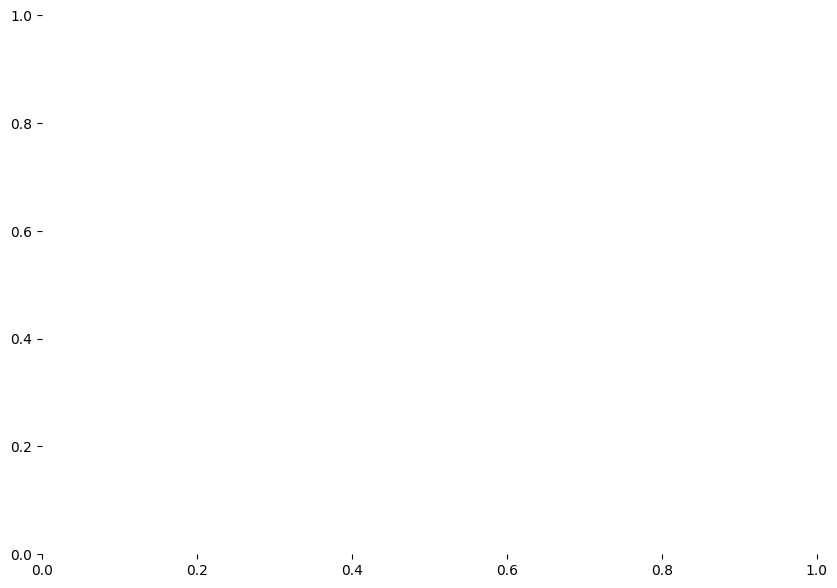

In [18]:
# Matriz OD por borough como heatmap
od_borough = df_od.groupby(['pickup_borough', 'dropoff_borough'])['trip_count'].sum().reset_index()
od_matrix = od_borough.pivot_table(
    values='trip_count',
    index='pickup_borough',
    columns='dropoff_borough',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(od_matrix.astype(float), annot=True, fmt=',.0f', cmap='YlOrRd',            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Número de viajes'})
ax.set_title('Matriz Origen-Destino: Viajes entre boroughs (junio 2015)', fontsize=13)
ax.set_xlabel('Borough de destino')
ax.set_ylabel('Borough de origen')
plt.tight_layout()
plt.show()

---
## 8. Comparación entre boroughs

Comparamos las métricas clave de cada borough: volumen de viajes, tarifa promedio, distancia, velocidad y propinas.

In [ ]:
# Estadísticas por borough
borough_stats = df_pickup.groupby('pickup_borough').apply(
    lambda g: pd.Series({
        'total_viajes': g['trip_count'].sum(),
        'n_zonas': len(g),
        'tarifa_ponderada': np.average(g['avg_fare'], weights=g['trip_count']),
        'distancia_ponderada': np.average(g['avg_distance'], weights=g['trip_count']),
        'propina_ponderada': np.average(g['avg_tip_pct'], weights=g['trip_count']),
    })
).round(2)

# Agregar velocidad
speed_borough = df_speed.groupby('pickup_borough').apply(
    lambda g: np.average(g['avg_speed_mph'], weights=g['trip_count'])
).round(2)
borough_stats['velocidad_ponderada'] = speed_borough

print("Comparación de métricas por borough:")
borough_stats.sort_values('total_viajes', ascending=False)

In [ ]:
# Visualización comparativa de boroughs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

boroughs_order = borough_stats.sort_values('total_viajes', ascending=False).index.tolist()
colors_map = {
    'Manhattan': '#E91E63', 'Brooklyn': '#2196F3', 'Queens/Otro': '#FF9800',
    'JFK': '#4CAF50', 'LaGuardia': '#9C27B0', 'Newark': '#795548'
}
colors = [colors_map.get(b, '#607D8B') for b in boroughs_order]

# 1. Total de viajes
axes[0, 0].barh(boroughs_order, [borough_stats.loc[b, 'total_viajes'] for b in boroughs_order],
                color=colors)
axes[0, 0].set_title('Total de viajes por borough')
axes[0, 0].set_xlabel('Número de viajes')

# 2. Tarifa promedio
axes[0, 1].barh(boroughs_order, [borough_stats.loc[b, 'tarifa_ponderada'] for b in boroughs_order],
                color=colors)
axes[0, 1].set_title('Tarifa promedio ponderada (USD)')
axes[0, 1].set_xlabel('USD')

# 3. Velocidad promedio
speed_vals = [borough_stats.loc[b, 'velocidad_ponderada']
              if b in speed_borough.index else 0 for b in boroughs_order]
axes[1, 0].barh(boroughs_order, speed_vals, color=colors)
axes[1, 0].set_title('Velocidad promedio ponderada (mph)')
axes[1, 0].set_xlabel('mph')

# 4. Propina promedio
axes[1, 1].barh(boroughs_order, [borough_stats.loc[b, 'propina_ponderada'] for b in boroughs_order],
                color=colors)
axes[1, 1].set_title('Propina promedio ponderada (%)')
axes[1, 1].set_xlabel('%')

fig.suptitle('Comparación de métricas entre boroughs (junio 2015)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Resumen del notebook

### Hallazgos geoespaciales clave

1. **Densidad de viajes**: Manhattan (especialmente Midtown) es por mucho la zona más activa
2. **Velocidad**: Inversamente proporcional a la densidad — más viajes = más tráfico = menos velocidad
3. **Propinas**: Varían por zona y borough, probablemente influenciadas por el tipo de cliente y duración del viaje
4. **Flujos OD**: La mayoría de los viajes son intra-Manhattan; los viajes al aeropuerto son un segmento importante
5. **Boroughs**: Manhattan domina en volumen pero tiene velocidades más bajas y tarifas por milla más altas

### Enfoque basado en Taxi Zones
Al no disponer de coordenadas GPS individuales, utilizamos los **location_id** (Taxi Zones TLC) con centroides aproximados. Este enfoque:
- Es más eficiente computacionalmente (datos ya agregados)
- Permite análisis a nivel de zona y borough
- Los mapas de calor usan pesos proporcionales al volumen real de viajes

### Siguientes pasos
- Notebook 06: Crear dashboards interactivos con Plotly para explorar estos patrones con controles dinámicos